In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score


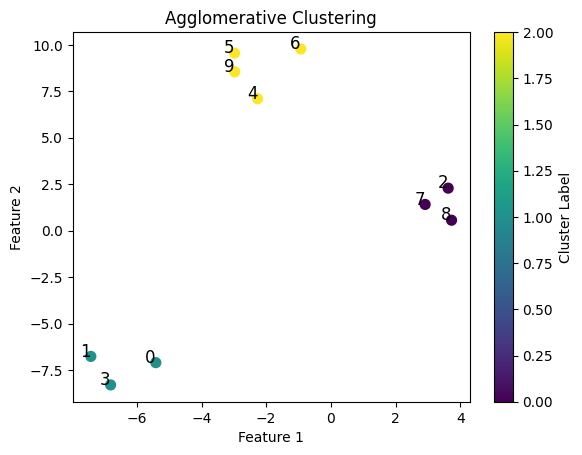

In [2]:
X, y = make_blobs(n_samples=10, centers=3, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="ward")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [3]:
n = X.shape[0]
node = model.cluster_nodes[1]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)) @ X
contrast = X.T@nu
ngrid=10
grid_width=15
stat_grid = np.linspace(-grid_width, grid_width, num=ngrid)

In [4]:
print(node)

ClusterNode(points=[0, 1, 3])


In [5]:
model._approx_log_reference(node, stat_grid, nuisance, contrast)

current step: 6
all winning pairs: [(ClusterNode(points=[7]), ClusterNode(points=[8])), (ClusterNode(points=[1]), ClusterNode(points=[3])), (ClusterNode(points=[4]), ClusterNode(points=[9])), (ClusterNode(points=[2]), ClusterNode(points=[7, 8])), (ClusterNode(points=[5]), ClusterNode(points=[4, 9])), (ClusterNode(points=[0]), ClusterNode(points=[1, 3])), (ClusterNode(points=[6]), ClusterNode(points=[5, 4, 9]))]
level:  6
grid value: -15.0
implied_mean [-127.62945626212738, -237.51598353592541, -222.65108471962824, 71.56070621576461, 168.11652745584217, 230.89752458368972, 152.85595622175623, -15.37139965927554, 104.65485340560241]
observed_opt [np.float64(-13.301174536277621), -110.80567920444159, -183.43613480341443, -222.21073067861283, -62.93927757630942, -1.065487890934361, -227.23819059570891, -325.1008319185873, -128.31755549530166]
grid value: -11.666666666666666
implied_mean [-162.02846077427947, -234.73341466473371, -237.2730664532925, -26.892313493864464, 77.07726041754431, 1

In [6]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

Distance Log:
(ClusterNode(points=[0]), ClusterNode(points=[1])): 2.0380364931244994
(ClusterNode(points=[0]), ClusterNode(points=[2])): 13.037418962158593
(ClusterNode(points=[0]), ClusterNode(points=[3])): 1.8418128827045737
(ClusterNode(points=[0]), ClusterNode(points=[4])): 14.551211837000686
(ClusterNode(points=[0]), ClusterNode(points=[5])): 16.83975525993707
(ClusterNode(points=[0]), ClusterNode(points=[6])): 17.472763390969146
(ClusterNode(points=[0]), ClusterNode(points=[7])): 11.912454405048726
(ClusterNode(points=[0]), ClusterNode(points=[8])): 11.934209188039876
(ClusterNode(points=[0]), ClusterNode(points=[9])): 15.843668027053912
(ClusterNode(points=[1]), ClusterNode(points=[2])): 14.288035244679854
(ClusterNode(points=[1]), ClusterNode(points=[3])): 1.653093983207061
(ClusterNode(points=[1]), ClusterNode(points=[4])): 14.797789518418515
(ClusterNode(points=[1]), ClusterNode(points=[5])): 16.920413362187247
(ClusterNode(points=[1]), ClusterNode(points=[6])): 17.7793395019

In [7]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")


Existing Clusters Log:
Merge: (ClusterNode(points=[7]), ClusterNode(points=[8])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9])]
Merge: (ClusterNode(points=[1]), ClusterNode(points=[3])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[9]), ClusterNode(points=[7, 8])]
Merge: (ClusterNode(points=[4]), ClusterNode(points=[9])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[2]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[9]), ClusterNode(points=[7, 8]), ClusterNode(points=[1, 3])]
Merge: (ClusterNode(points=[2]), ClusterNode(points=[7, 8])) -> Clusters: [C

In [8]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")
    break


Randomization Log:
1: {(ClusterNode(points=[0]), ClusterNode(points=[1])): 1.5284179003108858, (ClusterNode(points=[0]), ClusterNode(points=[2])): -0.7198010092054499, (ClusterNode(points=[0]), ClusterNode(points=[3])): -1.1975354444043091, (ClusterNode(points=[0]), ClusterNode(points=[4])): -0.6540303364790734, (ClusterNode(points=[0]), ClusterNode(points=[5])): 0.14485482315928044, (ClusterNode(points=[0]), ClusterNode(points=[6])): 0.5132010758865853, (ClusterNode(points=[0]), ClusterNode(points=[7])): -0.3214192778202682, (ClusterNode(points=[0]), ClusterNode(points=[8])): -2.96793054567779, (ClusterNode(points=[0]), ClusterNode(points=[9])): -0.5230256149692522, (ClusterNode(points=[1]), ClusterNode(points=[2])): 0.6266109203783643, (ClusterNode(points=[1]), ClusterNode(points=[3])): 0.5562061875808841, (ClusterNode(points=[1]), ClusterNode(points=[4])): 0.8170211798979907, (ClusterNode(points=[1]), ClusterNode(points=[5])): -0.9924114863964979, (ClusterNode(points=[1]), ClusterNo

In [9]:
np.shape(nuisance)

(10, 2)

In [10]:
np.shape(nu)

(10,)